In [99]:
import ee
import geemap
import json
import requests
import folium
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import io
import zipfile

from IPython.display import display, HTML, clear_output
from PIL import Image
from pyproj import Transformer   
from datetime import datetime  

## Import the raster file to get the metadata

We need the information from the raster as the json file needs to be in reference to the origin and transformation of the tif file.

Shape of the raster (rows, columns):
(3422, 4380)


Raster metadata:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 4380, 'height': 3422, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 134.42767203983848,
       0.0, -8.983152841195215e-05, -13.26479297989409)}


Affine transformation parameters:
| 0.00, 0.00, 134.43|
| 0.00,-0.00,-13.26|
| 0.00, 0.00, 1.00|


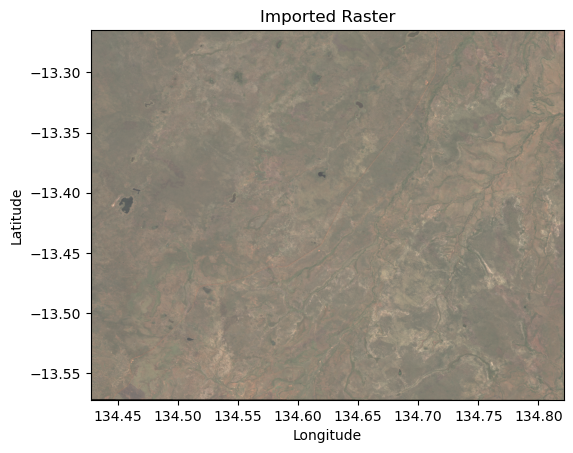

In [14]:
image_name = '2024-06_mimal_test_S2'

tif_base_dir = 'cookie-cutting/'
tif_path = os.path.join(tif_base_dir, image_name + '.tif')

with rasterio.open(tif_path) as raster:
    # Read the raster band
    imported_raster = raster.read(1)
    # Read the first three bands for an RGB preview
    rgb_raster = raster.read([1, 2, 3])
    rgb_raster = np.transpose(rgb_raster, (1, 2, 0))
    rgb_raster = rgb_raster.astype(np.float32)
    rgb_raster = (rgb_raster - rgb_raster.min()) / (rgb_raster.max() - rgb_raster.min() + 1e-9)
    # Get the metadata of the raster
    imported_raster_meta = raster.meta
    # Get the raster transform parameters
    raster_transform = raster.transform
    raster_bounds = raster.bounds

print("Shape of the raster (rows, columns):")
print(imported_raster.shape)
print("\n")

print("Raster metadata:")
print(imported_raster_meta)
print("\n")

print("Affine transformation parameters:")
print(raster_transform)

# Plot the raster as RGB using the original coordinates
import matplotlib.pyplot as plt
plt.imshow(
    rgb_raster,
    extent=(raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top),
    origin='upper',
)
plt.title('Imported Raster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Account for the png padding

As the png has padding, we need to figure out how much to add to the x and y coordinates to get the correct position for the labels in the png file.

This function will be different if there is padding on both sides and the top and bottom of the image. I've just accounted for padding on the left and top of the image by adding the difference in between the png size and the raster size to the x (difference in width) and y (difference in height) coordinates.

If the padding is consistent (e.g. tile_size - stride), we can just add that padding to the x and y coordinates. In that case, set width_diff and height_diff to the padding amount for the x and y axes respectively.

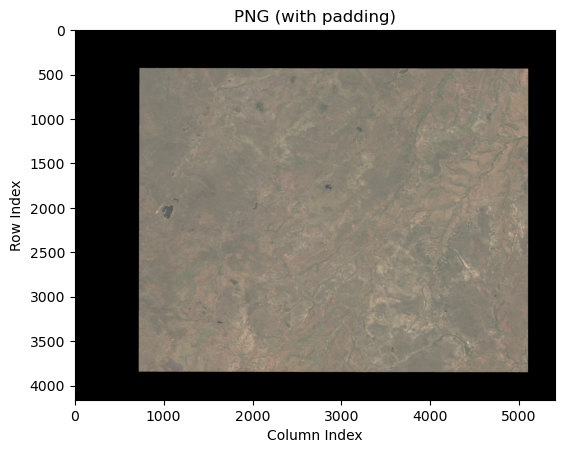

In [18]:
Image.MAX_IMAGE_PIXELS = 933120000 # change to greater than the nnumber of pixels (only needed if there's a warning)

# Base directory for the png image
png_base_dir = 'cookie-cutting/'

# Load the png image
image = Image.open(f'{png_base_dir}{image_name}.png')

# Convert the image to a numpy array
pixel_data = np.array(image)

# Plot the image data in the png to ensure they match
plt.imshow(pixel_data)
plt.title('PNG (with padding)')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

## Get image information

In [19]:
# Get image information
png_width, png_height = image.size
print(f'Image size: ({png_width}, {png_height})')

# Calculate the different in the width and height of the image and the raster
width_diff = png_width - imported_raster.shape[1]
height_diff = png_height - imported_raster.shape[0]
print(f'Difference in width: {width_diff}')
print(f'Difference in height: {height_diff}')


# if using images with padded left and right (and top and bottom)
tile_size = 416
stride = 104
min_pad = tile_size - stride
# subtract the padding on the right and bottom from the differences
width_diff = width_diff - min_pad
height_diff = height_diff - min_pad
print(f'Difference in width after removing right padding: {width_diff}')
print(f'Difference in height after removing bottom padding: {height_diff}')

Image size: (5408, 4160)
Difference in width: 1028
Difference in height: 738
Difference in width after removing right padding: 716
Difference in height after removing bottom padding: 426


In [22]:
json_path = os.path.join('cookie-cutting', f'{image_name}.json')
with open(json_path, 'r') as f:
    label_data = json.load(f)

# LabelMe stores box corners in PNG pixel coordinates, which include padding.
left_pad = (png_width - imported_raster.shape[1]) - min_pad
top_pad = (png_height - imported_raster.shape[0]) - min_pad

def png_pixel_to_lonlat(x_png, y_png):
    col = x_png - left_pad
    row = y_png - top_pad
    lon, lat = raster_transform * (col, row)
    return lon, lat

bbox_records = []
for shape in label_data['shapes']:
    (x1, y1), (x2, y2) = shape['points']
    x_min, x_max = sorted([x1, x2])
    y_min, y_max = sorted([y1, y2])

    corners = {
        'top_left': png_pixel_to_lonlat(x_min, y_min),
        'top_right': png_pixel_to_lonlat(x_max, y_min),
        'bottom_right': png_pixel_to_lonlat(x_max, y_max),
        'bottom_left': png_pixel_to_lonlat(x_min, y_max),
    }
    center_lon, center_lat = png_pixel_to_lonlat((x_min + x_max) / 2, (y_min + y_max) / 2)

    bbox_records.append({
        'label': shape['label'],
        'x_min_png': x_min,
        'y_min_png': y_min,
        'x_max_png': x_max,
        'y_max_png': y_max,
        'top_left_lon': corners['top_left'][0],
        'top_left_lat': corners['top_left'][1],
        'top_right_lon': corners['top_right'][0],
        'top_right_lat': corners['top_right'][1],
        'bottom_right_lon': corners['bottom_right'][0],
        'bottom_right_lat': corners['bottom_right'][1],
        'bottom_left_lon': corners['bottom_left'][0],
        'bottom_left_lat': corners['bottom_left'][1],
        'center_lon': center_lon,
        'center_lat': center_lat,
    })

bbox_df = pd.DataFrame(bbox_records)
bbox_df

,label,x_min_png,y_min_png,x_max_png,y_max_png,top_left_lon,top_left_lat,top_right_lon,top_right_lat,bottom_right_lon,bottom_right_lat,bottom_left_lon,bottom_left_lat,center_lon,center_lat
0,WH_wet,1485.210578,3469.863767,1502.729643,3483.531629,134.496771,-13.538228,134.498345,-13.538228,134.498345,-13.539456,134.496771,-13.539456,134.497558,-13.538842
1,Dry_WH,1317.820691,3607.445726,1337.607607,3617.246978,134.481735,-13.550587,134.483512,-13.550587,134.483512,-13.551468,134.481735,-13.551468,134.482623,-13.551027
2,WH_swamp,1597.312685,3269.092400,1671.329790,3303.405068,134.506842,-13.520192,134.513491,-13.520192,134.513491,-13.523275,134.506842,-13.523275,134.510166,-13.521733
3,WH_swamp,2211.721975,1735.673981,2347.609762,1819.685097,134.562035,-13.382443,134.574242,-13.382443,134.574242,-13.389990,134.562035,-13.389990,134.568139,-13.386216
4,WH_swamp,2215.493840,1590.519480,2316.212202,1656.841345,134.562374,-13.369404,134.571422,-13.369404,134.571422,-13.375361,134.562374,-13.375361,134.566898,-13.372382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Dry_WH,1444.160841,2087.533797,1455.555236,2094.994880,134.493084,-13.414051,134.494107,-13.414051,134.494107,-13.414721,134.493084,-13.414721,134.493596,-13.414386
183,WH_wet,1639.054061,647.528802,1682.246332,662.113332,134.510591,-13.284693,134.514471,-13.284693,134.514471,-13.286003,134.510591,-13.286003,134.512531,-13.285348
184,WH_sink,2963.556765,3767.487499,2985.879895,3779.599334,134.629573,-13.564964,134.631579,-13.564964,134.631579,-13.566052,134.629573,-13.566052,134.630576,-13.565508
185,WH_sink,4690.631632,1466.159258,4698.872432,1484.846193,134.784719,-13.358232,134.785460,-13.358232,134.785460,-13.359911,134.784719,-13.359911,134.785089,-13.359071


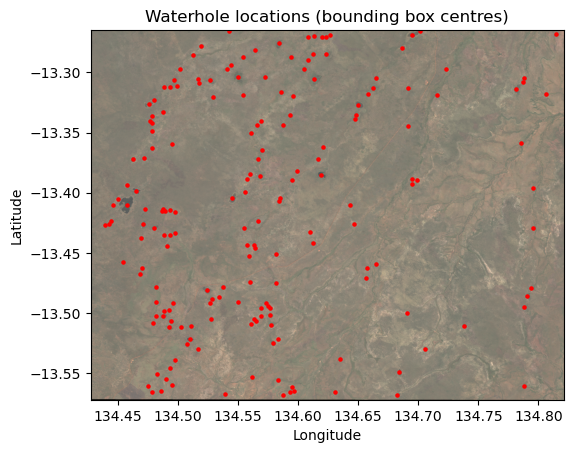

In [34]:
# Plot the centre points of the bounding boxes on the raster
plt.imshow(
    rgb_raster,
    extent=(raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top),
    origin='upper',
)
plt.scatter(bbox_df['center_lon'], bbox_df['center_lat'], c='red', s=5)
plt.title('Waterhole locations (bounding box centres)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()  

# Initialise GEE

You will need to authenticate your Google account the first time you run this. 

In [2]:
# Initialize Earth Engine
try:
    ee.Initialize()
    print("Earth Engine already initialized")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()
    print("Earth Engine initialized")


Successfully saved authorization token.
Earth Engine initialized


## Create AOIs from bounding box centres

Use the centres of the labelled bounding boxes as the AOI seed points, then buffer each one into a rectangular region for downstream sampling.

In [59]:
half_side_m = 750  # half the side length in metres

# Turn each bounding-box centre into a rectangular AOI
def bbox_center_to_rect(row):
    point = ee.Geometry.Point([float(row['center_lon']), float(row['center_lat'])])
    return ee.Feature(
        point.buffer(half_side_m).bounds(),
        {
            'lon': float(row['center_lon']),
            'lat': float(row['center_lat']),
            'label': row['label'],
        },
    )

rect_fc = ee.FeatureCollection([
    bbox_center_to_rect(row)
    for _, row in bbox_df.iterrows()
])
print(f'Created {bbox_df.shape[0]} AOIs from bounding-box centres')

Created 187 AOIs from bounding-box centres


### Plot the sampled AOIs

In [118]:
basemap = geemap.Map(lite_mode=True)
basemap.add_basemap("SATELLITE")
basemap.set_center(134.6, -13.425, 11)  # lon, lat, zoom — roughly central North Australia

# Style: red outlines, no fill
basemap.addLayer(
    rect_fc.style(color='red', fillColor='FF000033', width=2),  # last 2 hex digits = alpha
    {},
    'Sampled AOIs',
)

# basemap

# Clear previous outputs before displaying new map
clear_output(wait=True)
basemap.to_html(filename='satellite_map3.html')
HTML('satellite_map3.html')

# Get Sentinel-2 Collection with Cloud Masking

This function creates a cloud mask for Sentinel-2 imagery.

There are other approaches to filter clouds, such as the approach listed here: [https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).

In [61]:
def maskS2clouds_CSPlus(image):
    """
    Mask Sentinel-2 using Cloud Score+.
    Assumes the CS+ bands ('cs', 'cs_cdf') have already been linked
    to the S2 collection via linkCollection().
    """
    # Use the cs_cdf band (cumulative distribution function variant)
    # is generally more robust than 'cs' for time-series work.
    # Threshold range: 0 (not clear) to 1 (clear).
    #   0.60 = permissive (more pixels kept, some haze/thin cloud)
    #   0.65 = balanced (Google's commonly recommended default)
    #   0.80+ = strict (clean composites, fewer observations)
    QA_BAND = 'cs_cdf'
    CLEAR_THRESHOLD = 0.65

    mask = image.select(QA_BAND).gte(CLEAR_THRESHOLD)
    return (image.divide(10000)
                 .updateMask(mask)
                 .copyProperties(image, ['system:time_start']))

# Get Monthly Composites of Sentinel-2

## Define a function to get monthly composites

We want to create monthly composites of Sentinel-2 imagery. This function will filter the Sentinel-2 image collection by date and area of interest (AOI), apply the cloud mask, and then compute the median of each 'cloud-free' pixel for the month.

In [105]:
def get_monthly_composites(start_date, end_date, aoi):
    """Generate monthly S2 composites using Cloud Score+ for cloud/shadow masking."""
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    months = end.difference(start, 'month').round().int()
    optical_bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']

    # Load harmonized S2 SR and link Cloud Score+ bands once.
    # Pre-filter by AOI, date, and a generous cloud cover cap to drop the worst scenes
    # before the join.
    s2_base = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(aoi)
                 .filterDate(start_date, end_date)
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 90)))

    csPlus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
    s2_linked = s2_base.linkCollection(csPlus, ['cs', 'cs_cdf'])

    raw_count = s2_base.size().getInfo()
    print(f"  Found {raw_count} S2 images for {start_date} to {end_date}")

    composites_list = []

    for month_index in range(months.getInfo()):
        current_month_start = start.advance(month_index, 'month')
        current_month_end = current_month_start.advance(1, 'month')
        date_format = current_month_start.format('YYYY-MM').getInfo()

        # Filter the already-linked collection to this month and apply CS+ mask
        monthly = (s2_linked
                     .filterDate(current_month_start, current_month_end)
                     .map(maskS2clouds_CSPlus))

        monthly_count = monthly.size().getInfo()
        if monthly_count == 0:
            print(f'  Skipping {date_format}: no Sentinel-2 scenes')
            continue

        composite = monthly.median().clip(aoi).select(optical_bands)
        composites_list.append(composite.set({
            'system:index': date_format,
            'system:time_start': current_month_start.millis()
        }))

    composites = ee.ImageCollection.fromImages(composites_list)
    return composites

## Define a function to export and download images

If the images are small enough, you can download them directly to your local machine. If they are too large, you can export them to your Google Drive.

## For local export

In [106]:
# Local download of small images (e.g. for quick tests or small AOIs):
def export_monthly_images(composites, folder_path, aoi_name, scale=10):
    """Export monthly images to local files as multi-band GeoTIFFs."""
    # Create folder if it doesn't exist
    os.makedirs(folder_path, exist_ok=True)
    
    # Get the list of images
    image_list = composites.toList(composites.size())
    num_images = image_list.size().getInfo()
    
    # Loop through each image and export
    for i in range(num_images):
        image = ee.Image(image_list.get(i))
        date_str = image.get('system:index').getInfo()
        
        print(f"Processing image {i+1}/{num_images} for date {date_str}...")
        
        # Define output path
        geotiff_path = os.path.join(folder_path, f'{aoi_name}_{date_str}.tif')
        
        # Get download URL for the GeoTIFF
        download_url = image.getDownloadURL({
            'scale': scale,
            'crs': 'EPSG:4326',
            'fileFormat': 'GeoTIFF',
            'filePerBand': False,
            'region': image.geometry()
        })
        
        # Download the file
        response = requests.get(download_url, stream=True)
        response.raise_for_status()  # Raise an exception for HTTP errors
        
        # Earth Engine usually wraps GeoTIFF downloads in a ZIP archive.
        content = response.content
        if zipfile.is_zipfile(io.BytesIO(content)):
            with zipfile.ZipFile(io.BytesIO(content)) as archive:
                tif_name = next((name for name in archive.namelist() if name.lower().endswith('.tif')), None)
                if tif_name is None:
                    raise ValueError('Download archive did not contain a GeoTIFF')
                with archive.open(tif_name) as source, open(geotiff_path, 'wb') as target:
                    target.write(source.read())
        else:
            # Save the file directly if Earth Engine returns raw GeoTIFF bytes.
            with open(geotiff_path, 'wb') as f:
                f.write(content)
        
        print(f"Saved GeoTIFF: {geotiff_path}")

## For Google Drive export

In [107]:
# For larger or higher resolution images, use Google Drive export:
def export_to_drive(composites, aoi, aoi_name, drive_folder='Earth_Engine_Exports', scale=10):
    """Export each composite as a multi-band GeoTIFF to Google Drive."""
    image_list = composites.toList(composites.size())
    num_images = composites.size().getInfo()
    tasks = []

    for i in range(num_images):
        image = ee.Image(image_list.get(i))
        date_str = image.get('system:index').getInfo()

        task = ee.batch.Export.image.toDrive(
            image=image,
            description=f'{aoi_name}_{date_str}',
            folder=drive_folder,
            fileNamePrefix=f'{aoi_name}_{date_str}',
            scale=scale,
            region=aoi,
            crs='EPSG:4326',
            fileFormat='GeoTIFF',
            maxPixels=1e13,
        )
        task.start()
        tasks.append(task)
        print(f"Started: {aoi_name}_{date_str}")

    return tasks  # return so you can monitor with task.status()

# Download images for a specified date range

We will get an image for June 2024 as an example.

In [108]:
# Define parameters
start_date = '2024-01-01'
end_date = '2024-12-31'

output_folder = 'cookie-cutting/images/'

### Run the function

The function will print how many suitable images were found for the specified date range and AOI. If no images are found, you may need to adjust your date range or AOI.

In [109]:
# Grab the first AOI from the bounding-box-derived feature collection
first_aoi_feature = ee.Feature(rect_fc.first())
single_aoi = first_aoi_feature.geometry()

# Give the AOI a simple test name
single_name = 'first_aoi_test'
print(f'Testing first AOI: {single_name}')

# Get monthly composites for the first AOI only
composites = get_monthly_composites(start_date, end_date, single_aoi)

Testing first AOI: first_aoi_test
  Found 61 S2 images for 2024-01-01 to 2024-12-31


## Plot one of the randomly sampled AOIs

In [ ]:
# Visualize the first AOI test geometry
basemap = geemap.Map()
basemap.centerObject(single_aoi, zoom=15)
basemap.add_basemap("SATELLITE")
basemap.addLayer(single_aoi, {}, 'First nn

# Add the first image to the map
first_image = ee.Image(composites.first())
viz_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25}

# Get the number of images in the collection
count = composites.size().getInfo()
print(f"Found {count} monthly composites for {single_name}")

# Add each monthly composite to the map with its date as the layer name
if count > 0:
    # Convert to list for iterating
    date_strs = composites.aggregate_array('system:index').getInfo()
    image_list = composites.toList(count)
    
    # Add each image as a separate layer
    for i, date_str in enumerate(date_strs):
        image = ee.Image(image_list.get(i))
        basemap.addLayer(image, viz_params, f'S2 RGB {date_str}', shown=(i == 0))
           
    print(f"Added {count} layers to the map.")
else:
    print("No composites available to display.")

# Clear previous outputs before displaying new map
clear_output(wait=True)
basemap.to_html(filename='satellite_map2.html')
HTML('satellite_map2.html')

# Export images to Google Drive

## Set up parameters for exporting the images

In [111]:
# Convert the FeatureCollection to a list and get the count
rect_list = rect_fc.toList(rect_fc.size())
n = rect_fc.size().getInfo()
print(f'Number of AOIs: {n}')

lons = rect_fc.aggregate_array('lon').getInfo()
lats = rect_fc.aggregate_array('lat').getInfo()

def coord_tag(lat, lon):
    """e.g. lat=-42.8826, lon=147.3257 -> 'S42p88_E147p33'"""
    ns = 'S' if lat < 0 else 'N'
    ew = 'W' if lon < 0 else 'E'
    return f"{ns}{abs(lat):.2f}_{ew}{abs(lon):.2f}".replace('.', 'p')

base_name = image_name  # preserve the original AOI name for clarity

Number of AOIs: 187


# Export images

## Local export

In [117]:
print(f'Processing {n} AOIs...')

all_exports = []

for i in range(n):
    single_aoi = ee.Feature(rect_list.get(i)).geometry()
    tag = coord_tag(lats[i], lons[i])
    single_name = f'{base_name}_{i:03d}_{tag}'   
    
    print(f'\n[{i+1}/{n}] AOI: {single_name}')

    try:
        composites = get_monthly_composites(start_date, end_date, single_aoi)
        export_monthly_images(
            composites,
            folder_path=output_folder,
            aoi_name=single_name,
            scale=10,
        )
        all_exports.append(single_name)
    except Exception as e:
        print(f'  FAILED for {single_name}: {e}')
        continue

print(f'\nSaved local exports for {len(all_exports)} AOIs.')

Processing 187 AOIs...

[1/187] AOI: 2024-06_mimal_test_S2_000_S13p54_E134p50
  Found 61 S2 images for 2024-01-01 to 2024-12-31
Processing image 1/12 for date 2024-01...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-01.tif
Processing image 2/12 for date 2024-02...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-02.tif
Processing image 3/12 for date 2024-03...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-03.tif
Processing image 4/12 for date 2024-04...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-04.tif
Processing image 5/12 for date 2024-05...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-05.tif
Processing image 6/12 for date 2024-06...
Saved GeoTIFF: cookie-cutting/images/2024-06_mimal_test_S2_000_S13p54_E134p50_2024-06.tif
Processing image 7/12 for date 2024-07...
Saved GeoTIFF: cookie-cutting/images/2

## Google Drive export

In [ ]:
# print(f'Processing {n} AOIs for Drive export...')

# all_tasks = []

# for i in range(n):
#     single_aoi = ee.Feature(rect_list.get(i)).geometry()
#     tag = coord_tag(lats[i], lons[i])
#     single_name = f'{base_name}_{i:03d}_{tag}'   
    
#     print(f'\n[{i+1}/{n}] AOI: {single_name}')

#     try:
#         composites = get_monthly_composites(start_date, end_date, single_aoi)
#         tasks = export_to_drive(
#             composites,
#             aoi=single_aoi,
#             aoi_name=single_name,
#             drive_folder='sentinel2_images',
#             scale=10,
#         )
#         all_tasks.extend(tasks)
#     except Exception as e:
#         print(f'  FAILED for {single_name}: {e}')
#         continue

# print(f'\nStarted {len(all_tasks)} total Drive export tasks.')

### To check the status of the downloads

In [114]:
# print(f'Saved AOI exports: {len(all_exports)}') if 'all_exports' in globals() else print(f'Drive export tasks: {len(all_tasks)}')